# Photometric Analysis of NGC 1261 Globular Cluster Using HST FITS Images

In this python notebook, we will use FITS images of the globular cluster NGC 1261 taken
using the Hubble Space Telescope. Detect stars in the image, measure their magnitude
values using two filters, F275W and F336W, and try to generate a Colour Magnitude Diagram (CMD).

In [2]:
from astropy.io import fits
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

In [3]:
# fits_file = fits.open('sample_data/hlsp_hugs_hst_wfc3-uvis_ngc1261_f275w_v1_stack-0859s.fits',memmap=True)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
from astropy.io import fits
fits_file_275W = fits.open('/content/drive/MyDrive/Astropy_data/hlsp_hugs_hst_wfc3-uvis_ngc1261_f275w_v1_stack-0859s (1).fits',memmap=True)

In [7]:
fits_file_275W.info()

Filename: /content/drive/MyDrive/Astropy_data/hlsp_hugs_hst_wfc3-uvis_ngc1261_f275w_v1_stack-0859s (1).fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      40   (10000, 10000)   float32   


In [8]:
# extract data from the fits file
image_data_275W = fits_file_275W[0].data
print(image_data_275W)

[[-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 ...
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]]


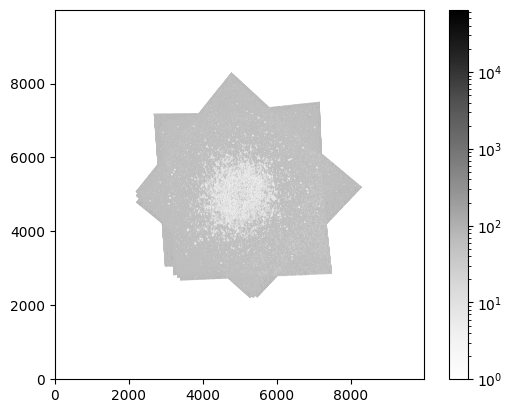

In [9]:
plt.figure()
plt.imshow(image_data_275W, origin = 'lower', cmap='Greys', norm=LogNorm())
plt.colorbar()
plt.show()

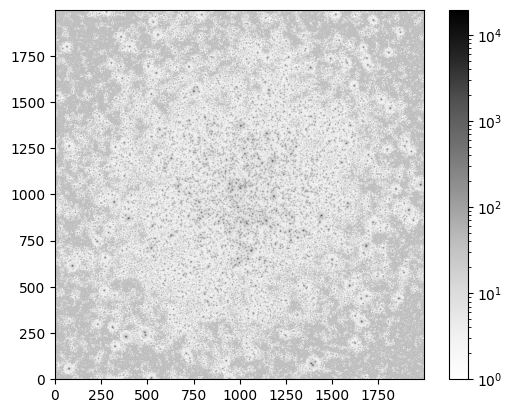

In [27]:
# zoom to specific region
section1_275W = image_data_275W[4000:6000, 4000:6000]

plt.figure()
plt.imshow(section1_275W, origin = 'lower', cmap='Greys', norm=LogNorm())
plt.colorbar()
plt.show()

In [28]:
header_1  = fits_file_275W[0].header
header_1

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                10000                                                  
NAXIS2  =                10000                                                  
EXTEND  =                    T                                                  
CRPIX1  =     0.5003061426E+04                                                  
CRPIX2  =     0.5000727417E+04                                                  
CRVAL1  =     0.4806754200E+02                                                  
CRVAL2  =    -0.5521622200E+02                                                  
CTYPE1  = 'RA---TAN'                                                            
CTYPE2  = 'DEC--TAN'                                                            
CD1_1   =   -0.109849110E-04

In [ ]:
RA_TARG =    48.06754166666666 / R.A. of cluster center (deg)
DEC_TARG=   -55.21622222222223 / Dec. of cluster center (deg)

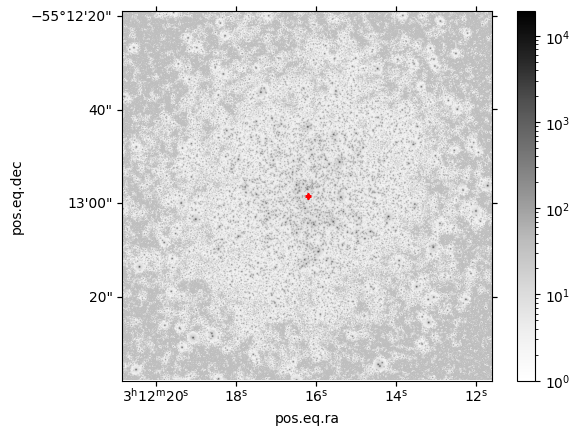

In [29]:
from astropy.wcs import WCS
center = SkyCoord(ra=48.06754*u.deg, dec=-55.21622*u.deg)
section1_275W = image_data_275W[4000:6000, 4000:6000]

px, py = wcs.world_to_pixel(center)

plt.figure()
plt.subplot(projection=wcs)
plt.imshow(section1_275W, origin = 'lower', cmap='Greys', norm=LogNorm())
plt.plot(px, py, '+', color='red', markersize=5, markeredgewidth=2, label='NGC 1261 center')
plt.colorbar()
plt.show()

In [30]:
from astropy.stats import sigma_clipped_stats
mean_1, median_1, std_1 = sigma_clipped_stats(section1_275W,sigma=3.0) ## done to remove background noise as stars will have bright pixels
# print data
print((mean_1,median_1,std_1))

(np.float32(2.5964355), np.float32(2.0), np.float32(2.4665616))


In [31]:
!pip install photutils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 21.4 MB/s eta 0:00:00


In [32]:
from photutils.detection import DAOStarFinder
daofind       = DAOStarFinder(fwhm=3.0, threshold=5.0*std_1)
sources_275W  = daofind(section1_275W - median_1)

In [33]:
sources_275W = daofind(section1_275W - median_1)
print(sources_275W.colnames)

['id', 'x_centroid', 'y_centroid', 'sharpness', 'roundness1', 'roundness2', 'n_pixels', 'peak', 'flux', 'mag', 'daofind_mag']


In [34]:
import numpy as np
from photutils.aperture import CircularAperture

In [35]:
## Bright stars   → foreground, not part of NGC1261
##                  too bright, ruin our measurements
##                  MASK THEM → ignore completely

## Faint stars    →  actual NGC1261 cluster members
##                   (blue circles)    these are what we came to study
##                    measure their brightness → science!

In [36]:
bright_limit_1  = median_1 + 50*std_1
mask_1          = section1_275W > bright_limit_1
sources_bs_275W = daofind(section1_275W - median_1, mask=mask_1)
print(f"Stars detected after masking: {len(sources_bs_275W)}")

Stars detected after masking: 3291


## Setting Up Apertures

For each detected star we place:
- A **circular aperture** (radius = 6 pixels) to collect the star's light
- A **circular annulus** (ring from radius 10 to 15 pixels) around it to sample the local background

In [37]:
xpix_1      = sources_bs_275W['x_centroid']
ypix_1      = sources_bs_275W['y_centroid']
positions_1 = np.transpose((xpix_1, ypix_1))
apertures_1 = CircularAperture(positions_1, r=6.0)

In [38]:
from photutils.aperture import CircularAnnulus, CircularAperture, ApertureStats, aperture_photometry

# define annuluses
annulus_aperture_1 = CircularAnnulus(positions_1, r_in=10, r_out=15)

In [39]:
from astropy.stats import SigmaClip
sigma_clip         = SigmaClip(sigma=3.0)
aperstats_1        = ApertureStats(section1_275W, annulus_aperture_1, sigma_clip=sigma_clip)
bkg_mean_275W = aperstats_1.mean

aperture_area_275W = apertures_1.area_overlap(section1_275W)
total_bkg_275W = bkg_mean_275W*aperture_area_275W

In [40]:
# perform aperture photometry
star_data_275W = aperture_photometry(section1_275W, apertures_1)  # sum of the pixels of the stars

# add backgrounds to table
star_data_275W['total_bkg'] = total_bkg_275W

# format and print data
for col in star_data_275W.colnames:
    star_data_275W[col].info.format = '%.8g'

star_data_275W.pprint()

 id   x_center  y_center  aperture_sum total_bkg
---- --------- ---------- ------------ ---------
   1 163.59364 0.21256202    176.54267 39.305301
   2 713.77164 0.12964306    322.37856  138.3196
   3 1405.8203 0.40283063    128.94289 46.746847
   4  280.4909  1.2160121    971.70088 199.03872
   5 1036.2936  1.4236963    722.24289 85.155025
   6 1630.5638  1.3366346    878.37462 85.166507
   7 680.72968  2.4669262    502.30914 213.05622
   8 1361.3974  2.5515669    653.84691 80.232095
   9 1605.0482  4.4780861    742.56977 81.812931
  10 192.98575  6.4555607    854.23466 71.318842
 ...       ...        ...          ...       ...
3282 418.19383  1995.2386    851.12512 65.927769
3283 1030.0258  1994.7196    265.68733 89.298645
3284 1637.4479  1995.6571    749.51729 161.09715
3285 1732.3097  1996.2405    210.03227 64.638582
3286 650.77574  1997.0626    190.61434   84.5797
3287 968.42823  1996.5065    295.10982 211.72485
3288 301.41664   1998.797    489.15319 154.49478
3289 570.07082  1998

In [41]:
header_1  = fits_file_275W[0].header
filter_1  = header_1['FILTER']
extime_1  = header_1['EXPTIME']

In [42]:
## MAGNITUDE = ZEROPOINT - 2.5*log_10{(APERTURE_SUM - TOTAL_BKG)/EXTIME}

In [43]:
import math

## Zeropoints

The zeropoints used in this notebook are taken from the official STScI WFC3 zeropoint table.

| Filter | ABMag Zeropoint |
|--------|----------------|
| F275W  | 24.158         |
| F336W  | 24.692         |

Source: [STScI WFC3 Zeropoints Notebook](https://spacetelescope.github.io/hst_notebooks/notebooks/WFC3/zeropoints/zeropoints.html)

In [44]:
zeropoint_1 = 24.158

In [45]:
star_data_275W['net_flux'] = star_data_275W['aperture_sum'] - star_data_275W['total_bkg']
# remove stars with negative net flux before taking log
good_flux = star_data_275W['net_flux'] > 0
star_data_275W = star_data_275W[good_flux]

print(f"Stars removed due to negative flux: {(~good_flux).sum()}")
print(f"Stars remaining: {good_flux.sum()}")

star_data_275W['magnitude'] = zeropoint_1 - 2.5 * np.log10(star_data_275W['net_flux'] / extime_1)

star_data_275W[:10].pprint(max_width=-1)

Stars removed due to negative flux: 151
Stars remaining: 3140
 id  x_center  y_center  aperture_sum total_bkg  net_flux magnitude
--- --------- ---------- ------------ --------- --------- ---------
  1 163.59364 0.21256202    176.54267 39.305301 137.23737 28.539813
  2 713.77164 0.12964306    322.37856  138.3196 184.05896 28.221101
  3 1405.8203 0.40283063    128.94289 46.746847 82.196039 29.096366
  4  280.4909  1.2160121    971.70088 199.03872 772.66216 26.663519
  5 1036.2936  1.4236963    722.24289 85.155025 637.08787 26.872995
  6 1630.5638  1.3366346    878.37462 85.166507 793.20811 26.635026
  7 680.72968  2.4669262    502.30914 213.05622 289.25292 27.730299
  8 1361.3974  2.5515669    653.84691 80.232095 573.61482 26.986943
  9 1605.0482  4.4780861    742.56977 81.812931 660.75684 26.833389
 10 192.98575  6.4555607    854.23466 71.318842 782.91582 26.649206


In [46]:
##New file

In [47]:
from astropy.io import fits
fits_file = fits.open('/content/drive/MyDrive/Astropy_data/hlsp_hugs_hst_wfc3-uvis_ngc1261_f336w_v1_stack-0413s.fits', memmap=True)

In [48]:
# extract data from the fits file
image_data = fits_file[0].data
print(image_data)

[[-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 ...
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]
 [-25. -25. -25. ... -25. -25. -25.]]


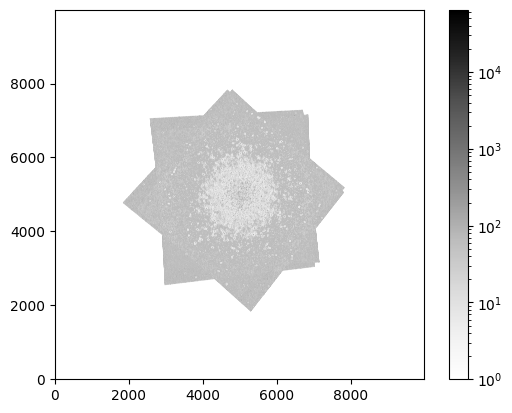

In [49]:
plt.figure()
plt.imshow(image_data, origin = 'lower', cmap='Greys', norm=LogNorm())
plt.colorbar()
plt.show()

## Overlaying F275W and F336W Images Using WCS

To confirm both filters cover the same sky region, we overlay the F275W (grey) and F336W (hot colormap) images using their respective WCS solutions.

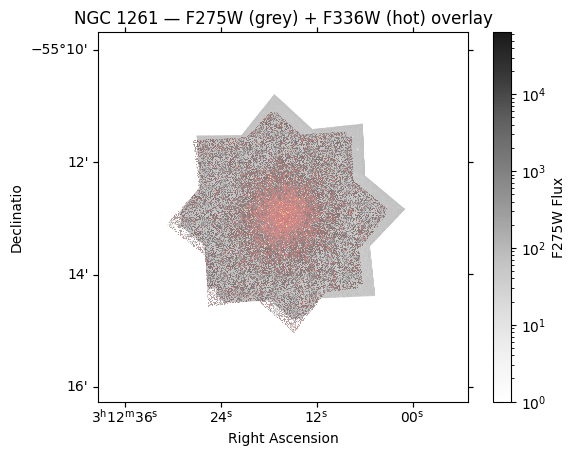

In [69]:
from astropy.wcs import WCS

wcs_275 = WCS(fits_file_275W[0].header)
wcs_336 = WCS(fits_file[0].header)

fig = plt.figure()
ax = fig.add_subplot(111, projection=wcs_275)  # base WCS is F275W

#Plot F275W as base image ---
ax.imshow(image_data_275W, origin='lower', cmap='Greys', norm=LogNorm(), alpha=0.9)

#Overlay F336W using its own WCS ---
ax.imshow(image_data, origin='lower', cmap='hot', norm=LogNorm(), alpha=0.4,
          transform=ax.get_transform(wcs_336))

ax.set_xlabel('Right Ascension')
ax.set_ylabel('Declinatio')
ax.set_title('NGC 1261 — F275W (grey) + F336W (hot) overlay')
plt.colorbar(ax.images[0], ax=ax, label='F275W Flux')
plt.show()

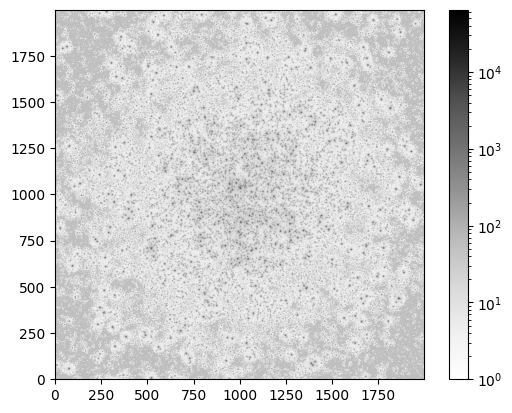

In [56]:
# zoom to specific region
section1 = image_data[4000:6000, 4000:6000]

plt.figure()
plt.imshow(section1, origin = 'lower', cmap='Greys', norm=LogNorm())
plt.colorbar()
plt.show()

In [57]:
from astropy.stats import sigma_clipped_stats
mean, median, std = sigma_clipped_stats(section1,sigma=3.0) ## done to remove background noise as stars will have bright pixels
# print data
print((mean,median,std))

(np.float32(5.2822204), np.float32(4.0), np.float32(5.268965))


In [58]:
daofind = DAOStarFinder(fwhm = 3.0, threshold = 5.0*std)
sources = daofind(section1 - median)

In [59]:
bright_limit = median + 50*std ## to bright stars
mask = section1 > bright_limit

sources_bs = daofind(section1 - median, mask=mask)
print(f"Stars detected after masking: {len(sources_bs)}")
xpix = sources_bs['x_centroid']
ypix = sources_bs['y_centroid']
positions = np.transpose((xpix,ypix))
apertures = CircularAperture(positions,r=6.0)

Stars detected after masking: 4127


In [60]:
from photutils.aperture import CircularAnnulus, CircularAperture, ApertureStats, aperture_photometry

# define annuluses
annulus_aperture = CircularAnnulus(positions, r_in=10, r_out=15)

In [61]:
sigma_clip = SigmaClip(sigma=3.0)
aperstats  = ApertureStats(section1, annulus_aperture, sigma_clip=sigma_clip)

bkg_mean = aperstats.mean

aperture_area = apertures.area_overlap(section1)
total_bkg = bkg_mean*aperture_area

# perform aperture photometry
star_data_336W = aperture_photometry(section1, apertures) #sum of the pixels of the stars

# add backgrounds to table
star_data_336W['total_bkg'] = total_bkg

# format and print data
for col in star_data_336W.colnames:
    star_data_336W[col].info.format = '%.8g'

star_data_336W.pprint()

 id   x_center  y_center  aperture_sum total_bkg
---- --------- ---------- ------------ ---------
   1 163.49516 0.12219002    316.39604 51.841251
   2 713.78647 0.15610451    672.84225 250.13572
   3 1405.8266 0.38286785    448.32561 84.050364
   4 1036.2141  1.3652269    1523.7952 108.39124
   5 1630.5182  1.3236085    1896.0077 157.41997
   6 819.95604   2.276152     380.6523 87.837487
   7 680.81887  2.4746378    1290.7759 341.05928
   8 1361.3104  2.4606764    1556.6637  138.0798
   9  1696.017   2.991906    578.84295 430.78863
  10 1605.0883  4.5915708    1852.8008 203.46913
 ...       ...        ...          ...       ...
4118 980.72704  1996.5181    481.15636 634.10541
4119 1457.3247  1995.9869    608.77211  269.3271
4120 1637.5403   1995.635    1868.9455 294.18744
4121 650.66902   1997.155     648.3746 104.36558
4122 968.49444  1996.4846    1026.4155 394.24384
4123 1197.7978  1997.1135    551.41294 195.29071
4124 383.99568  1998.9095    237.49789 97.671065
4125 570.06601  1998

In [62]:
header  = fits_file[0].header
filter  = header['FILTER']
extime  = header['EXPTIME']

In [63]:
extime

1662.0

In [64]:
zeropoint = 24.692

extime = 1662.0

star_data_336W['net_flux']  = star_data_336W['aperture_sum'] - star_data_336W['total_bkg']

good_flux_2 = star_data_336W['net_flux'] > 0
star_data_336W = star_data_336W[good_flux_2]

print(f"Stars removed due to negative flux: {(~good_flux).sum()}")
print(f"Stars remaining: {good_flux.sum()}")

star_data_336W['magnitude'] = zeropoint - 2.5 * np.log10(star_data_336W['net_flux'] / extime)

star_data_336W[:10].pprint(max_lines=-1, max_width=-1)

Stars removed due to negative flux: 151
Stars remaining: 3140
 id  x_center  y_center  aperture_sum total_bkg  net_flux magnitude
--- --------- ---------- ------------ --------- --------- ---------
  1 163.49516 0.12219002    316.39604 51.841251 264.55479 26.687288
  2 713.78647 0.15610451    672.84225 250.13572 422.70653  26.17848
  3 1405.8266 0.38286785    448.32561 84.050364 364.27525 26.340003
  4 1036.2141  1.3652269    1523.7952 108.39124  1415.404 24.866377
  5 1630.5182  1.3236085    1896.0077 157.41997 1738.5877 24.643086
  6 819.95604   2.276152     380.6523 87.837487 292.81482 26.577095
  7 680.81887  2.4746378    1290.7759 341.05928 949.71663 25.299592
  8 1361.3104  2.4606764    1556.6637  138.0798 1418.5839  24.86394
  9  1696.017   2.991906    578.84295 430.78863 148.05432 27.317525
 10 1605.0883  4.5915708    1852.8008 203.46913 1649.3317 24.700308


## Matching Stars Between the Two Filters

The F275W and F336W images were taken separately, so the same star will appear
at slightly different pixel positions in each image. I use a **KD Tree** to find the nearest neighbour match for each
star between the two catalogues.

Only accept a match if the two detections are within 3 pixels of each other.
Anything further apart is likely a different star or a bad detection.

In [ ]:
from scipy.spatial import cKDTree

# build tree from 275W positions
pos_275 = np.transpose((np.array(star_data_275W['x_center']), np.array(star_data_275W['y_center'])))
tree = cKDTree(pos_275)

# match each 336W star to nearest 814W star
pos_336 = np.transpose((np.array(star_data_336W['x_center']), np.array(star_data_336W['y_center'])))

#KD Tree
distances, idx = tree.query(pos_336, k=1)

# keep only matches within 3 pixels
matched = distances < 3.0

print(f"Stars in 275W:       {len(star_data_275W)}")
print(f"Stars in F336W:       {len(star_data_336W)}")
print(f"Matched stars:        {matched.sum()}")

Stars in 275W:       3140
Stars in F336W:       3877
Matched stars:        2653


## Plotting the Colour-Magnitude Diagram

This is an attempt at plotting the CMD using the matched stars between both filters.
The colour is computed by subtracting `F336W magnitude` from `F275W magnitude` and
plotted against the F275W magnitude.

The y-axis is inverted because in astronomy, lower magnitude numbers mean brighter stars —
so brighter stars sit at the top. The x-axis shows colour, where smaller values mean
bluer (hotter) stars.

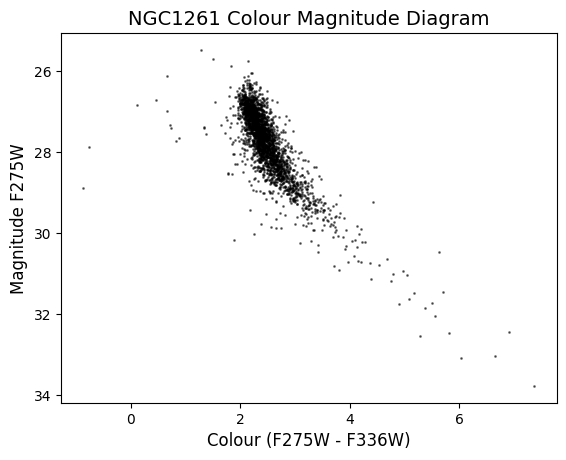

In [ ]:
# matched is a mask over 336W stars
mag_336 = np.array(star_data_336W['magnitude'])[matched]

# idx[matched] gives the index into 275W for each matched 336W star
mag_275 = np.array(star_data_275W['magnitude'])[idx[matched]]

colour = mag_275 - mag_336

# plot CMD
import matplotlib.pyplot as plt
plt.scatter(colour, mag_275, s=1, color='black', alpha=0.5)
plt.gca().invert_yaxis()
plt.xlabel('Colour (F275W - F336W)', fontsize=12)
plt.ylabel('Magnitude F275W', fontsize=12)
plt.title('NGC1261 Colour Magnitude Diagram', fontsize=14)
plt.show()